<a href="https://colab.research.google.com/github/lisagamilton/python_tasks_logical/blob/main/pandas_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


https://drive.google.com/file/d/1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX/view?usp=sharing

https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists?resource=download

In [1]:
! gdown --id 1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xbXbLi6CyIhmWTPj6_zYysNdKEsAcVLX
To: /content/HR_analytics.zip
100% 302k/302k [00:00<00:00, 4.91MB/s]


In [2]:
! unzip /content/HR_analytics.zip

Archive:  /content/HR_analytics.zip
  inflating: aug_test.csv            
  inflating: aug_train.csv           
  inflating: sample_submission.csv   


In [18]:
import pandas as pd
df = pd.read_csv('/content/aug_train.csv')
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


In [4]:
import seaborn as sns

In [8]:
t = df.pivot_table(index='education_level',columns='gender',values='target')
t

gender,Female,Male,Other
education_level,,,
Graduate,0.279431,0.257122,0.330357
High School,0.268657,0.182796,0.181818
Masters,0.247788,0.191410,0.074074
Phd,0.127660,0.132143,0.250000
Primary School,0.250000,0.093596,0.333333


In [12]:
t = df.pivot_table(index='education_level',columns='gender',values='target',aggfunc='mean')
t

gender,Female,Male,Other
education_level,,,
Graduate,0.279431,0.257122,0.330357
High School,0.268657,0.182796,0.181818
Masters,0.247788,0.191410,0.074074
Phd,0.127660,0.132143,0.250000
Primary School,0.250000,0.093596,0.333333


<Axes: xlabel='gender', ylabel='education_level'>

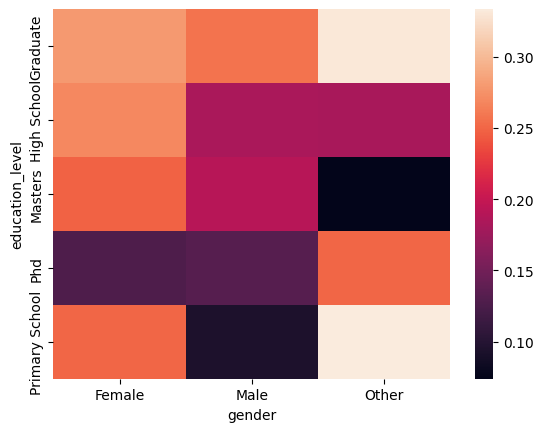

In [13]:
sns.heatmap(t)

In [22]:
df['city_development_index_group_q'] = pd.qcut(df['city_development_index'],5,duplicates='drop')

In [23]:
df.groupby('city_development_index_group_q',dropna=False)['target'].agg(['count','mean'])

/tmp/ipykernel_2576/3018231713.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('city_development_index_group_q',dropna=False)['target'].agg(['count','mean'])


,count,mean
city_development_index_group_q,,
"(0.447, 0.691]",3869,0.550530
"(0.691, 0.878]",3827,0.206428
"(0.878, 0.92]",8925,0.178375
"(0.92, 0.949]",2537,0.104454


In [31]:
t = df.groupby('city')['target'].agg(['count','mean'])
t

,count,mean
city,,
city_1,26,0.115385
city_10,86,0.104651
city_100,275,0.236364
city_101,75,0.573333
city_102,304,0.171053
...,...,...
city_93,26,0.192308
city_94,26,0.384615
city_97,104,0.076923


<Axes: xlabel='city'>

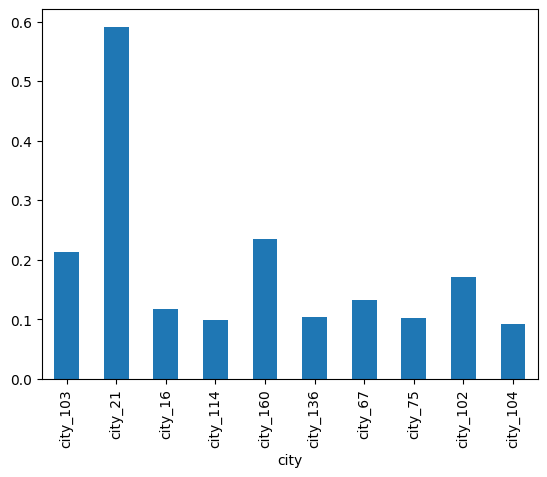

In [34]:
t.sort_values('count',ascending=False).head(10)['mean'].plot(kind='bar')

In [41]:
df['experience_int'] = df['experience'].replace('<1','0').replace('>20','999').fillna(-1).astype(int)

In [43]:
df['experience_group'] = pd.qcut(df['experience_int'],5)
df['experience_group']

,experience_group
0,"(18.0, 999.0]"
1,"(11.0, 18.0]"
2,"(4.0, 6.0]"
3,"(-1.001, 4.0]"
4,"(18.0, 999.0]"
...,...
19153,"(11.0, 18.0]"
19154,"(11.0, 18.0]"
19155,"(18.0, 999.0]"
19156,"(-1.001, 4.0]"


In [44]:
df.groupby('experience_group')['target'].agg(['count','mean'])

/tmp/ipykernel_2576/775867775.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('experience_group')['target'].agg(['count','mean'])


,count,mean
experience_group,,
"(-1.001, 4.0]",5020,0.358964
"(4.0, 6.0]",2646,0.285336
"(6.0, 11.0]",4459,0.239740
"(11.0, 18.0]",3295,0.170561
"(18.0, 999.0]",3738,0.157571


The less years of experience - the more they want to change jobs. Visualization:

/tmp/ipykernel_2576/4070535839.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('experience_group')['target'].agg(['count','mean'])['mean'].plot(kind='bar')


<Axes: xlabel='experience_group'>

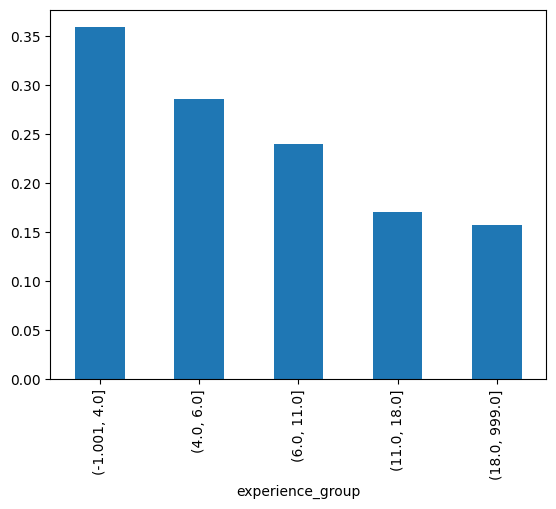

In [47]:
df.groupby('experience_group')['target'].agg(['count','mean'])['mean'].plot(kind='bar')

In [52]:
t = pd.DataFrame({'col1':[1,2,3,float('nan')],
                  'col2':['a','b','c','d'],
                  'col3':[0]*3 + [1]*1})
t

,col1,col2,col3
0,1.0,a,0
1,2.0,b,0
2,3.0,c,0
3,NaN,d,1


In [54]:
df['exp_num'] = df['experience'].replace({'>20': 21, '<1': 0}).astype(float)
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,city_development_index_group_q,experience_int,experience_group,exp_num
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,"(0.878, 0.92]",999,"(18.0, 999.0]",21.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,"(0.691, 0.878]",15,"(11.0, 18.0]",15.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,"(0.447, 0.691]",5,"(4.0, 6.0]",5.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,"(0.691, 0.878]",0,"(-1.001, 4.0]",0.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,"(0.691, 0.878]",999,"(18.0, 999.0]",21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0,"(0.691, 0.878]",14,"(11.0, 18.0]",14.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0,"(0.878, 0.92]",14,"(11.0, 18.0]",14.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0,"(0.878, 0.92]",999,"(18.0, 999.0]",21.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0,"(0.691, 0.878]",0,"(-1.001, 4.0]",0.0


In [55]:
df['training_group'] = pd.cut(
    df['training_hours'],
    bins=[0, 50, 100, 400],
    labels=['low','medium','high']
)

df.groupby('training_group')['target'].mean()

/tmp/ipykernel_2576/69252597.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('training_group')['target'].mean()


,target
training_group,
low,0.255469
medium,0.245438
high,0.238366


In [56]:
t = df.groupby(['education_level','relevent_experience'])['target'].mean().reset_index()

t.sort_values('target', ascending=False).head(3)

,education_level,relevent_experience,target
1,Graduate,No relevent experience,0.428519
5,Masters,No relevent experience,0.320153
3,High School,No relevent experience,0.241909
